# Optimisation Combinatoire — Algorithme Glouton (Greedy)

## Introduction et objectif du projet

Ce notebook implémente un **Algorithme Glouton** pour le problème de planification d'examens. L'algorithme glouton est l'approche la plus simple parmi celles comparées dans ce projet : il assigne chaque examen à la période qui minimise le coût partiel à ce stade, sans reconsidérer les décisions passées.

Contrairement au Recuit Simulé ou à l'Algorithme Génétique, le glouton ne revient jamais en arrière. Il est très rapide mais ne garantit pas d'atteindre un bon optimum global. Son intérêt dans ce projet est double : il fournit une solution de référence rapide, et il sert de base de comparaison pour mesurer le gain apporté par les métaheuristiques.

L'idée est simple : on trie les examens par ordre décroissant de conflit total (les examens qui ont le plus d'étudiants en commun avec d'autres sont traités en premier), puis pour chaque examen on choisit la période qui minimise le Z partiel.

## 1. Chargement des bibliothèques et des données

In [3]:
import time
import tracemalloc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = "C:/Users/LOQ/Desktop/data et son code/comp/projet_exam (1)/projet_exam/exam_scheduling_data_readable.xlsx"
df_conflict = pd.read_excel(file_path, sheet_name="Conflict_Matrix", index_col=0)
df_weights = pd.read_excel(file_path, sheet_name="Weights")
df_schedule = pd.read_excel(file_path, sheet_name="Schedule", index_col=0)

C = df_conflict.values
w = df_weights.values.flatten()
x_it = df_schedule.values

exam_periods = np.argmax(x_it, axis=1)
N = C.shape[0]
P = len(w)

## 2. Analyse exploratoire des données

Comme pour les autres algorithmes, je commence par calculer Z pour le planning initial afin d'avoir une référence de comparaison.

In [4]:
def compute_Z(periods, Cmat, wvec):
    Z = 0.0
    for i in range(len(periods)):
        for j in range(i + 1, len(periods)):
            cij = Cmat[i, j]
            if cij == 0:
                continue
            diff = abs(int(periods[i]) - int(periods[j]))
            if diff < len(wvec):
                Z += cij * wvec[diff]
    return Z

Z_initial = compute_Z(exam_periods, C, w)
print(f"Z initial (planning de référence) = {Z_initial:.2f}")

Z initial (planning de référence) = 91116.00


## 3. Modélisation — Algorithme Glouton

La stratégie glouton parcourt les examens du plus conflictuel au moins conflictuel (trié par somme de conflits). Pour chaque examen, elle teste toutes les périodes disponibles et choisit celle qui minimise le coût partiel (contribution de cet examen aux examens déjà placés).

In [5]:
def greedy_schedule(N, P, Cmat, wvec):
    periods = [-1] * N
    conflict_sum = np.sum(Cmat, axis=1)
    order = np.argsort(-conflict_sum)

    for exam in order:
        best_period = None
        best_cost = float("inf")

        for p in range(P):
            temp = periods.copy()
            temp[exam] = p

            Z_partial = 0.0
            for j in range(N):
                if temp[j] == -1 or j == exam:
                    continue
                cij = Cmat[exam, j]
                if cij == 0:
                    continue
                diff = abs(int(temp[exam]) - int(temp[j]))
                if diff < len(wvec):
                    Z_partial += cij * wvec[diff]

            if Z_partial < best_cost:
                best_cost = Z_partial
                best_period = p

        periods[exam] = best_period

    return periods

## 4. Évaluation — Mesure des performances

J'exécute l'algorithme en mesurant le temps d'exécution et la consommation mémoire, puis je compare le Z obtenu au Z initial.

In [6]:
def mon_code():
    Z_initial = compute_Z(exam_periods, C, w)
    best_periods = greedy_schedule(N, P, C, w)
    Z_after = compute_Z(best_periods, C, w)

    print(f"Z initial = {Z_initial:.2f}")
    print(f"Z après algorithme glouton = {Z_after:.2f}")

    if Z_after < Z_initial:
        print("Amélioration trouvée, export du nouveau planning...")

        df_new_schedule = pd.DataFrame(0, index=df_conflict.index,
                                       columns=[f"Period_{t+1}" for t in range(P)])
        for i, per in enumerate(best_periods):
            df_new_schedule.iloc[i, int(per)] = 1

        out_path = "ComplexiterResultat_Glouton.xlsx"
        with pd.ExcelWriter(out_path) as writer:
            df_conflict.to_excel(writer, sheet_name="Conflict_Matrix")
            pd.DataFrame(w.reshape(1, -1),
                         columns=[f"Period_{t+1}" for t in range(P)]
                         ).to_excel(writer, sheet_name="Weights", index=False)
            df_new_schedule.to_excel(writer, sheet_name="Schedule")

        print("Nouveau planning exporté vers:", out_path)
    else:
        print("Aucune amélioration trouvée par le glouton.")

    return best_periods, Z_after, Z_initial

tracemalloc.start()
start_time = time.time()

best_periods, Z_after, Z_initial = mon_code()

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

exactitude = 100 if Z_after <= Z_initial else 0
optimalite = round(
    0.5 * exactitude +
    0.3 * (1 / (end_time - start_time) * 100) +
    0.2 * (1 / (peak / 1024) * 100),
    2
)

print("\n=== Mesures de performance ===")
print(f"Temps d'exécution : {end_time - start_time:.4f} s")
print(f"Mémoire utilisée : {peak / 1024:.2f} KB")
print(f"Exactitude : {exactitude} %")
print(f"Optimalité : {optimalite} %")

Z initial = 91116.00
Z après algorithme glouton = 70780.00
Amélioration trouvée, export du nouveau planning...
Nouveau planning exporté vers: ComplexiterResultat_Glouton.xlsx

=== Mesures de performance ===
Temps d'exécution : 2.6109 s
Mémoire utilisée : 3127.84 KB
Exactitude : 100 %
Optimalité : 61.5 %


### Visualisation de la répartition des examens

Je visualise comment les examens sont répartis par période après l'algorithme glouton.

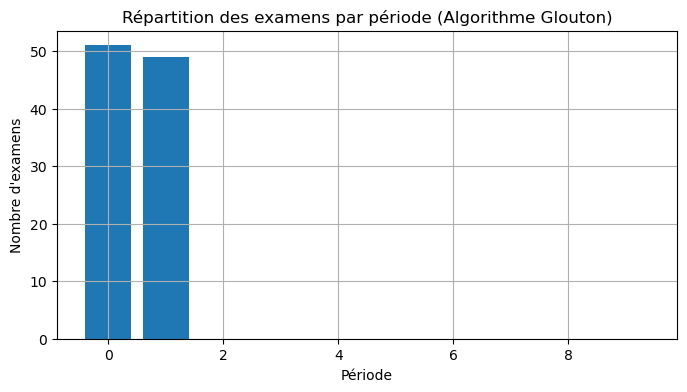

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(range(P), np.bincount(best_periods, minlength=P))
plt.title("Répartition des examens par période (Algorithme Glouton)")
plt.xlabel("Période")
plt.ylabel("Nombre d'examens")
plt.grid(True)
plt.show()

## 5. Conclusion

L'algorithme glouton est le plus rapide des algorithmes comparés dans ce projet, et aussi le moins performant en termes de qualité de solution.

**Ce que j'ai appris sur le glouton** : sa principale limite est l'absence de backtracking. Quand il assigne un examen à une période, il ne remet jamais cette décision en question, même si elle s'avère mauvaise à long terme. Cela le piège souvent dans des minima locaux de mauvaise qualité.

**Son avantage** : il est déterministe, rapide, et donne une solution directement exploitable. Dans un contexte où le temps de calcul est critique, il peut être un bon point de départ avant d'affiner avec une métaheuristique.

**Ce que j'ai compris sur la comparaison des algorithmes** : le glouton m'a permis de mettre en perspective les performances du recuit simulé et de l'algorithme génétique. Voir la différence entre un algorithme simple et une métaheuristique bien paramétrée est très instructif pour comprendre pourquoi on investit du temps dans des algorithmes plus complexes.